# Active Learning: Which Compounds Should Be Measured Next?

A companion to `Boiling_Point_Predicter.ipynb`. That notebook concludes the model is data-limited and recommends collecting more compounds with **large polar area and/or many rotatable bonds**. That was done once with a hand-written rule, `polararea >= 40 or rotbonds >= 14` (5,400 NIST lookups, 105 hits).

This notebook asks whether **letting a model choose** which compounds to label improves the ensemble faster than that rule, or than random picks.

## Active learning, not Bayesian optimisation

Both use the same loop: a surrogate model predicts a value and an uncertainty, an acquisition rule picks what to measure next, the new labels are added, and the model is refit. They differ in the goal:

| | Bayesian optimisation | Active learning (this notebook) |
|---|---|---|
| Goal | Find the best compound | Make the model accurate everywhere |
| Picks by | Predicted value + uncertainty | Uncertainty only |
| Success measure | Experiments until the best is found | Test error per labelled compound |

## Two models, two jobs

| Role | Model | Job |
|---|---|---|
| **Selector** (picks compounds) | GP, or a bootstrap XGBoost ensemble | Retrained every round on all labels so far; picks the next batch |
| **Production model** | The Ridge + XGBoost + NN ensemble from the main notebook | Retrained at checkpoints on the labels so far; its test RMSE is the success measure |

The selector never gets the final say on quality. Every strategy, including the model-free ones, is judged by how good the production ensemble gets on the data it chose.

**Gaussian process (GP).** Predicts a boiling point as a similarity-weighted combination of known compounds and reports how sure it is. Its uncertainty grows with distance from anything already labelled, which is what should flag an under-represented region. The kernel learns one length scale per feature (ARD) plus a noise level. The noise absorbs isomers that share all 12 features but differ in boiling point (225 such groups, median spread ~5 K). Batches are chosen greedily: pick the most uncertain compound, condition the GP on it, then pick again. This keeps a batch from being 25 isomers of the same alkane.

**Strategies compared**
1. `random`: uniform picks.
2. `heuristic`: random picks inside the hard region until it runs out, i.e. the rule behind the NIST collection.
3. `gp_uncertainty`: GP posterior uncertainty with conditioned batches (BoTorch `SingleTaskGP`).
4. `bootstrap_xgb`: the 25 compounds with the largest spread across 15 bootstrapped XGBoost models.

In [1]:
import sys
sys.path.insert(0, "src")
sys.path.insert(0, "scripts")

# boiling_point first: it loads xgboost before torch (see src/boiling_point/__init__.py)
from boiling_point import active_learning, features, viz

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from run_active_learning_simulation import load_dataset, TEST_SPLIT_SEED

## Simulation setup

It's a retrospective simulation: all 1,693 labels (literature + NIST) are known, but each campaign pretends only 50 random ones are, then reveals more in rounds.

- **Fixed test set:** 20%, stratified on the hard region so it has enough hard compounds. Every strategy and seed uses the same test set.
- **Schedule:** 50 random starting labels, shared by all strategies for a given seed. Then batches of 25 up to 550 labels, where strategies should differ most, then batches of 100 until the pool is used up.
- **Checkpoints:** the production ensemble (fixed hyperparameters from the main notebook's re-tune) is retrained and scored at 50, 100, 200, 300, 400 and 550 labels, then every round.
- **10 seeds** per strategy.
- **GP kernel settings** are re-optimised only when the labelled set has grown 20%, and reused in between. On this data one optimisation takes minutes at ~1,000 compounds.

In [2]:
df = load_dataset()
hard = features.in_hard_region(df).to_numpy()
pool_idx, test_idx = train_test_split(np.arange(len(df)), test_size=0.2, stratify=hard,
                                      random_state=TEST_SPLIT_SEED)
pd.Series({
    "labelled compounds": len(df),
    "in hard region": int(hard.sum()),
    "test set": len(test_idx),
    "test set, hard region": int(hard[test_idx].sum()),
    "simulation pool": len(pool_idx),
    "batch sizes": f"{len(active_learning.batch_schedule(len(pool_idx)))} rounds: 25 per round to 550 labels, then 100",
})

labelled compounds                                                  1693
in hard region                                                       379
test set                                                             339
test set, hard region                                                 76
simulation pool                                                     1354
batch sizes              29 rounds: 25 per round to 550 labels, then 100
dtype: object

The simulation takes about 10 minutes on 9 cores, so it runs as a script and this notebook loads the results:

```bash
python scripts/run_active_learning_simulation.py --seeds 10
```

In [3]:
results = pd.read_csv("results/active_learning_simulation.csv")
picks = pd.read_csv("results/active_learning_picks.csv")
results.groupby("strategy")["seed"].nunique().rename("seeds")

strategy
bootstrap_xgb     10
gp_uncertainty    10
heuristic         10
random            10
Name: seeds, dtype: int64

## Result 1: model-driven and rule-based picking both beat random

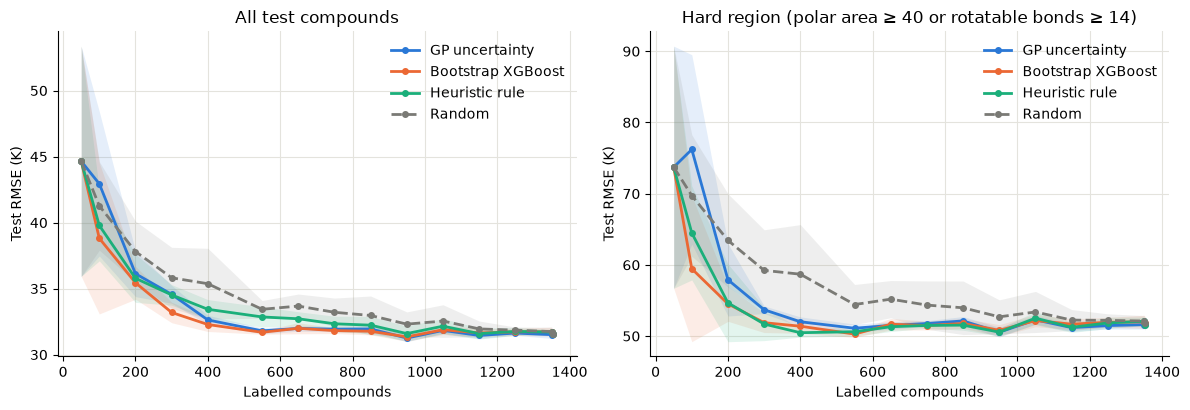

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
viz.plot_active_learning_curves(results, "rmse", ax=axes[0], title="All test compounds")
viz.plot_active_learning_curves(results, "rmse_hard", ax=axes[1],
                                title="Hard region (polar area ≥ 40 or rotatable bonds ≥ 14)")
plt.show()

In [5]:
budgets = [100, 200, 300, 400, 550, 850, int(results["n_labels"].max())]
summary = (results[results["n_labels"].isin(budgets)]
           .groupby(["n_labels", "strategy"])[["rmse", "rmse_hard"]]
           .agg(["mean", "std"]).round(1))
summary

rmse      rmse_hard      
                         mean  std      mean   std
n_labels strategy                                 
100      bootstrap_xgb   38.8  5.7      59.5  10.2
         gp_uncertainty  42.9  5.5      76.2  13.3
         heuristic       39.8  2.7      64.5   6.6
         random          41.3  3.4      69.7   8.5
200      bootstrap_xgb   35.4  1.2      54.5   2.5
         gp_uncertainty  36.1  1.7      57.9   5.1
         heuristic       35.8  1.8      54.7   5.5
         random          37.8  2.3      63.4   6.5
300      bootstrap_xgb   33.2  0.8      51.9   1.4
         gp_uncertainty  34.6  0.7      53.7   0.5
         heuristic       34.5  0.8      51.7   2.3
         random          35.8  2.3      59.2   5.7
400      bootstrap_xgb   32.3  0.5      51.4   1.0
         gp_uncertainty  32.6  0.3      52.0   0.7
         heuristic       33.4  0.7      50.5   0.6
         random          35.4  2.7      58.7   7.0
550      bootstrap_xgb   31.7  0.1      50.3   0.5
         gp_uncertainty  31.8  0.2      51.1   0.6
         heuristic       32.9  0.8      50.6   0.6
         random          33.4  0.7      54.4   2.8
850      bootstrap_xgb   31.8  0.3      51.8   0.7
         gp_uncertainty  31.9  0.2      52.1   0.6
         heuristic       32.2  0.7      51.5   0.7
         random          33.0  1.5      54.0   3.8
1354     bootstrap_xgb   31.6  0.3      51.9   0.8
         gp_uncertainty  31.5  0.3      51.6   0.6
         heuristic       31.5  0.3      51.6   0.8
         random          31.6  0.3      51.8   0.7

**Reading the curves**

- **Built-in check:** at the full pool every strategy has labelled the same compounds, so all four end at the same RMSE (~31.6 K overall, ~52 K in the hard region). They do.
- **Between ~200 and ~550 labels, every non-random strategy beats random.** At 400 labels the overall test RMSE is 32.3 K (bootstrap XGBoost), 32.6 K (GP), 33.4 K (heuristic) and 35.4 K (random). Compared seed by seed against random at 400 labels, the GP and bootstrap selectors win 10/10 seeds and the heuristic 8/10.
- **Chosen data is also more consistent.** Random's seed-to-seed spread at 400 labels is ±2.7 K; the other three strategies are within ±0.7 K.
- **The GP starts worse than random.** At 100 labels it is behind on both panels (42.9 vs 41.3 K overall; 76 vs 70 K in the hard region). Result 3 explains why.
- **Everything flattens out after ~550 labels.** Result 4 covers what that means.

## How many labels does choosing well save?

For each strategy: how many labels it needs to reach the RMSE that **random** reaches at a given budget (linearly interpolated on the seed-averaged curves).

In [6]:
pd.concat({
    "all test compounds": active_learning.labels_to_match(results, metric="rmse"),
    "hard region": active_learning.labels_to_match(results, metric="rmse_hard"),
}, axis=1).round(0)

all test compounds                                  \
                   bootstrap_xgb gp_uncertainty heuristic random   
random budget                                                      
200                        130.0          175.0     149.0  200.0   
400                        203.0          249.0     233.0  400.0   
550                        289.0          358.0     400.0  550.0   

                hard region                                  
              bootstrap_xgb gp_uncertainty heuristic random  
random budget                                                
200                    86.0          170.0     111.0  200.0  
400                   116.0          196.0     159.0  400.0  
550                   203.0          283.0     208.0  550.0

To match random's accuracy at 550 labels, bootstrap XGBoost needs about **290 labels (~47% fewer)**, the GP about **360 (~35% fewer)** and the heuristic rule about **400 (~27% fewer)**. In the hard region the savings are larger, and the heuristic does as well as the best model (both ~200–210 labels vs 550). That's expected, since the rule was written for that region.

**The GP was not the best selector.** Going in, I expected the GP to win, because tree ensembles tend to be over-confident when extrapolating. Here the bootstrap XGBoost ensemble was slightly better at every budget. This fits published materials-science benchmarks, where tree-ensemble surrogates are often competitive with GPs.

## Result 2: the models rediscover the hand-written rule

The share of labelled compounds that fall in the hard region, for each strategy (the whole pool is 22% hard):

In [7]:
where = (results[results["n_labels"].isin([100, 200, 300, 400, 550])]
         .groupby(["n_labels", "strategy"])["frac_hard_labelled"].mean()
         .unstack("strategy").round(2))
where["whole pool"] = round(hard[pool_idx].mean(), 2)
where

strategy,bootstrap_xgb,gp_uncertainty,heuristic,random,whole pool
n_labels,,,,,
100,0.57,0.47,0.60,0.20,0.22
200,0.68,0.52,0.80,0.22,0.22
300,0.60,0.50,0.87,0.22,0.22
400,0.55,0.47,0.76,0.22,0.22
550,0.48,0.42,0.55,0.22,0.22


In [8]:
# The first 25 compounds each model-driven strategy chose after the shared
# 50 random starting labels (seed 0)
first = picks[(picks["seed"] == 0) & (picks["order"].between(50, 74))]
pd.DataFrame({
    s: first[first["strategy"] == s]["cmpdname"].to_numpy()
    for s in ["gp_uncertainty", "bootstrap_xgb"]
}).join(pd.DataFrame({
    f"{s} hard?": first[first["strategy"] == s]["hard_region"].to_numpy()
    for s in ["gp_uncertainty"]
}))

,gp_uncertainty,bootstrap_xgb,gp_uncertainty hard?
0,Tripentaerythritol,Dinitrochlorobenzene,True
1,Ozone,Tetranitromethane,True
2,Pentaethylenehexamine,4'-Nitroacetophenone,True
3,Tetranitromethane,Dehydroacetic acid,True
4,Lycopene,2-Nitromesitylene,True
5,Tetracyanoethylene,"2,6,10,14-Tetramethyl-2-hexadecene",True
6,(2H4)Methane,Pyruvic Acid,False
7,Mannitol,1-Eicosene,True
8,Methanediol,1-Triacontene,True
9,N-Methyldioctadecylamine,1-Nonacosene,True


Without being told about the hard region, both model-driven selectors spend 50–70% of their labels in it, versus 22% for random picks. The hand-written rule was a good rule: the models found the same region by themselves, and the rule-based strategy matches them on hard-region accuracy.

## Result 3: pure uncertainty sampling chases oddballs first

The GP's first picks are the most unusual compounds in the pool: ozone, deuterated methane, tetranitromethane, lycopene, tetracyanoethylene, mannitol. These are the extremes of the 12-feature space. They are genuinely far from everything labelled, so the GP is rightly uncertain about them, but they are not representative of the test set. That's why the GP is *behind* random at 100 labels. This is a known weakness of uncertainty-only sampling. Common fixes are to weight uncertainty by how many similar compounds a candidate represents (density-weighted sampling) or to start from a larger, diverse initial set.

## Side result: how accurate are the selectors themselves?

In [9]:
(results.dropna(subset=["selector_rmse"])
 .groupby(["n_labels", "strategy"])[["selector_rmse", "rmse"]].mean()
 .rename(columns={"selector_rmse": "selector's own test RMSE", "rmse": "ensemble test RMSE"})
 .unstack("strategy").loc[[100, 200, 400, 550, 850]].round(1))

selector's own test RMSE                ensemble test RMSE  \
strategy            bootstrap_xgb gp_uncertainty      bootstrap_xgb   
n_labels                                                              
100                          46.6           48.0               38.8   
200                          38.2           37.2               35.4   
400                          33.9           33.4               32.3   
550                          33.7           32.4               31.7   
850                          32.6           31.8               31.8   

                         
strategy gp_uncertainty  
n_labels                 
100                42.9  
200                36.1  
400                32.6  
550                31.8  
850                31.9

At 400–550 labels the GP's own test RMSE (~32–33 K) is close to the production ensemble's. So the GP is a reasonable regressor on these features, not only a picker.

It degrades late in the campaign, though (≈38 K at the full pool). This happens exactly when its kernel settings are re-optimised on ~1,000+ compounds: the optimiser shrinks one feature's length scale to ~0.03 and overfits. A from-scratch fit at 1,150 labels does even worse (45.8 K), so this is a property of maximum-likelihood fitting on this data, not of the warm start. It affects only the phase where all strategies have already converged. A lower bound on the length scales would be the standard fix.

## Why did bootstrap XGBoost beat the GP?

Does each selector's uncertainty point at where the production ensemble is actually wrong? To keep the comparison fair, both selectors and the ensemble are fitted on the **same** labels (random's labelled sets at 100, 200 and 400 labels, 10 seeds). Then, on the test set:

- **`rho_ensemble`**: Spearman correlation between the selector's uncertainty and the ensemble's absolute error. This is what matters for active learning. (`rho_own` does the same against the selector's own error.)
- **`rho_distance`**: correlation between uncertainty and distance to the nearest labelled compound.
- **`hard_over_easy`**: mean uncertainty in the hard region divided by mean uncertainty elsewhere, to compare with the same ratio for the ensemble's actual error.
- **`top10_error_ratio`**: the ensemble's error on the 10% of compounds the selector is most unsure about, relative to its average error.

In [10]:
from joblib import Parallel, delayed

def calibration_run(seed, n_labels):
    order = (picks[(picks["seed"] == seed) & (picks["strategy"] == "random")]
             .sort_values("order")["row"].to_numpy())
    return active_learning.uncertainty_calibration(
        X, y, hard, order[:n_labels], test_idx, seed=seed).assign(seed=seed)

X = features.select_model_features(df).to_numpy(dtype=float)
y = features.get_target(df).to_numpy(dtype=float)
calibration = pd.concat(Parallel(n_jobs=-1)(
    delayed(calibration_run)(seed, n) for seed in range(10) for n in (100, 200, 400)))
(calibration.drop(columns="seed")
 .groupby(["n_labels", "selector"]).mean().round(2))

rho_own  rho_ensemble  rho_distance  hard_over_easy  \
n_labels selector                                                              
100      bootstrap_xgb      0.56          0.48          0.49            3.27   
         gp_uncertainty     0.58          0.52          0.81            2.28   
200      bootstrap_xgb      0.60          0.57          0.58            3.75   
         gp_uncertainty     0.53          0.53          0.81            2.43   
400      bootstrap_xgb      0.61          0.61          0.59            3.68   
         gp_uncertainty     0.50          0.50          0.80            2.32   

                         ensemble_error_hard_over_easy  top10_error_ratio  
n_labels selector                                                          
100      bootstrap_xgb                            3.01               2.68  
         gp_uncertainty                           3.01               2.45  
200      bootstrap_xgb                            2.95               3.11  
         gp_uncertainty                           2.95               2.55  
400      bootstrap_xgb                            2.87               3.00  
         gp_uncertainty                           2.87               2.24

- **The GP's uncertainty is mostly geometric.** It correlates with distance to the nearest labelled compound at ρ ≈ 0.8 at every budget. That's expected: with fixed kernel settings, a GP's variance depends only on where the labelled points are, not on their boiling points. Bootstrap disagreement depends on the labels. It's only partly about distance (ρ ≈ 0.5–0.6) and also reflects where predictions are genuinely unstable.
- **The GP underestimates how much harder the hard region is.** The ensemble's real error is ~3× larger there. The bootstrap spread says ~3.3–3.7×; the GP says ~2.3×. The GP assumes one noise level everywhere, so its uncertainty can't grow with local difficulty.
- **So bootstrap XGBoost points at the ensemble's mistakes better as data grows.** The GP is slightly ahead at 100 labels, but from 200 labels on bootstrap tracks the ensemble's error better (ρ ≈ 0.57–0.61 vs ≈ 0.50–0.53). Its 10% most-uncertain picks carry ~3× the average error (GP: ~2.2–2.5×).
- **What this doesn't settle:** bootstrap tracks its own error and the ensemble's about equally, so part of its edge may come from being similar to the ensemble's XGBoost member. Also, test compounds come from the same distribution as the pool. For genuinely novel candidates, like many of Part B's 10,776, the GP's distance-based caution may matter more.

## Result 4: the hard region hits a floor

From about 400 labels onward, hard-region RMSE sits at **~50–52 K for every strategy**. Labelling the rest of the pool doesn't move it. So within this dataset, the hard-region error is not limited by how many compounds are labelled. It's limited by what the 12 features can express, and possibly by label errors (the main notebook found two likely ~100 K data-entry errors among the recurring outliers). The GP's learned noise level of ~21–25 K points the same way: that is scatter the features can't explain.

This refines the main notebook's recommendation to collect more hard-region data: **more compounds described by the same 12 features will probably not fix the hard region.** Richer molecular descriptors, and auditing the labels, are likely the bigger levers.

## Part B: a real model-driven NIST round (not yet run)

`scripts/run_model_driven_nist_round.py` is the real-world counterpart of the simulation. It ranks the 10,776 PubChem candidates with NIST-likely names, with no region filter, by selector uncertainty. It looks them up in rounds of 100 (reusing cached results from the heuristic run) until it has 105 hits or has done 3,000 lookups. The resulting compounds can then be compared with the 105 heuristic-chosen ones. Given Result 4, the expected effect on the hard region is small, which is itself worth confirming with real new data.

## Conclusions

1. **Choosing which compounds to label pays off early.** All three non-random strategies reach random's 550-label accuracy with ~27–47% fewer labels, and give more consistent results across seeds.
2. **Bootstrap XGBoost was the best selector**, the GP second and the hand-written rule close behind. In the hard region the rule matched the models: domain knowledge captured most of the benefit. The calibration check suggests why bootstrap won: its uncertainty follows where predictions are unstable, while the GP's mostly follows distance from labelled data and underestimates how hard the hard region is.
3. **Uncertainty-only GP sampling has a cold-start problem.** It first picks chemical extremes (ozone, deuterated methane), which hurts accuracy at ~100 labels.
4. **The hard region has a ~50 K error floor** in this dataset that more labels don't lower. The next improvement probably needs better features or cleaner labels, not just more of the same data.